# Synthetic simulation matching the thesis DGP

This notebook generates the synthetic panel used for the simulation experiments. It intentionally follows the thesis data-generating process exactly:

```text
x_t -> p_{t+1} -> c_{t+1}
```

The macro variables `x_t` are persistent, so the latent stress probability evolves smoothly over time. Conditional on that probability, the realised regime and charge-off rate remain stochastic. The `stress_regime` variable is only a temporary Bernoulli indicator used to sample from the two-component Gaussian mixture; it does not create persistence by itself.


## 1. Imports and shared capital-allocation functions

The simulation uses NumPy, pandas, SciPy's logistic function, and matplotlib. Oracle allocations and utilities reuse the project's shared capital-allocation functions and parameter conventions.


In [104]:
from __future__ import annotations

from dataclasses import dataclass, field
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from scipy.special import expit
import matplotlib.pyplot as plt

if "seaborn-v0_8-whitegrid" in plt.style.available:
    plt.style.use("seaborn-v0_8-whitegrid")
elif "seaborn-whitegrid" in plt.style.available:
    plt.style.use("seaborn-whitegrid")
else:
    plt.style.use("default")

pd.set_option("display.max_columns", 100)


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "models" / "src").exists() and (candidate / "models" / "simulation" / "data").exists():
            return candidate
    raise RuntimeError("Could not find repo root. Set REPO_ROOT manually in this cell.")


REPO_ROOT = find_repo_root()
MODELS_SRC = REPO_ROOT / "models" / "src"
if str(MODELS_SRC) not in sys.path:
    sys.path.insert(0, str(MODELS_SRC))

from capital_allocation_utils import CapitalConfig, optimise_oracle_alpha, realised_utility

print(f"Repo root: {REPO_ROOT}")


Repo root: /Users/hannahokeeffe/Documents/Imperial/DFL_New


## 2. Configuration

The macro variables are simulated as persistent AR/VAR-style processes. The true stress probability is generated directly from contemporaneous macro covariates as

```text
p_{t+1} = sigmoid(gamma_0 + x_t' gamma)
```

The charge-off mixture parameters and capital-allocation parameters are preserved from the empirically calibrated project defaults. The only probability object is `p_true`, which directly governs the mixture draw.


In [115]:
MACRO_NAMES = ["activity", "labour_market_stress", "financial_conditions"]


@dataclass
class SimulationConfig:
    """Configuration for the thesis-DGP synthetic panel."""

    T: int = 500
    start_date: str = "2000-01-01"
    freq: str = "QS"

    # Persistent macro process: x_t = A x_{t-1} + epsilon_t.
    A: np.ndarray = field(default_factory=lambda: np.array([
        [0.78, -0.05, -0.04],
        [-0.04, 0.72, 0.10],
        [-0.03, 0.12, 0.70],
    ], dtype=float))
    Sigma_x: np.ndarray = field(default_factory=lambda: np.array([
        [0.30, -0.08, -0.06],
        [-0.08, 0.25, 0.09],
        [-0.06, 0.09, 0.28],
    ], dtype=float))

    # Higher activity lowers stress probability; higher labour-market stress and
    # tighter financial conditions raise stress probability.
    gamma_0: float = -1.75
    gamma: np.ndarray = field(default_factory=lambda: np.array([-0.85, 0.95, 0.85], dtype=float))

    # Empirically calibrated Gaussian-mixture charge-off parameters.
    mu_normal: float = CapitalConfig().mu_normal
    sigma_normal: float = CapitalConfig().sigma_normal
    mu_stress: float = CapitalConfig().mu_stress
    sigma_stress: float = CapitalConfig().sigma_stress

    # Preserve capital-allocation parameter convention used downstream.
    capital: CapitalConfig = field(default_factory=lambda: CapitalConfig(lgd=0.45, leverage=10.0))


config = SimulationConfig()

print("VAR eigenvalue moduli:", np.round(np.abs(np.linalg.eigvals(config.A)), 3))
print("Sigma_x eigenvalues:", np.round(np.linalg.eigvalsh(config.Sigma_x), 3))
print("Stress equation gamma:", dict(zip(MACRO_NAMES, config.gamma)))
print("Charge-off mixture parameters:")
print({
    "mu_normal": config.mu_normal,
    "sigma_normal": config.sigma_normal,
    "mu_stress": config.mu_stress,
    "sigma_stress": config.sigma_stress,
})
print("Capital parameters:", config.capital)


VAR eigenvalue moduli: [0.86 0.74 0.6 ]
Sigma_x eigenvalues: [0.168 0.232 0.43 ]
Stress equation gamma: {'activity': np.float64(-0.85), 'labour_market_stress': np.float64(0.95), 'financial_conditions': np.float64(0.85)}
Charge-off mixture parameters:
{'mu_normal': 0.0061, 'sigma_normal': 0.0042, 'mu_stress': 0.0143, 'sigma_stress': 0.0067}
Capital parameters: CapitalConfig(lgd=0.45, y_bar=0.05, lambda_penalty=10.0, maturity=2.5, leverage=10.0, mu_normal=0.0061, sigma_normal=0.0042, mu_stress=0.0143, sigma_stress=0.0067, pd_floor=1e-06, pd_cap=0.99, alpha_eps=1e-08)


## 3. Simulation function

`p_true` is the single latent stress probability governing the charge-off mixture. The realised `stress_regime` is drawn independently each quarter conditional on `p_true`, and is used only to choose which Gaussian component supplies `charge_off_rate`.

The charge-off draw is exactly the two-component Gaussian mixture in the thesis DGP. It is not smoothed or transformed for visual appearance.


In [116]:
def simulate_macro_covariates(config: SimulationConfig, rng: np.random.Generator) -> np.ndarray:
    x = np.zeros((config.T, len(MACRO_NAMES)), dtype=float)
    for t in range(1, config.T):
        epsilon_t = rng.multivariate_normal(np.zeros(len(MACRO_NAMES)), config.Sigma_x)
        x[t] = config.A @ x[t - 1] + epsilon_t
    return x


def simulate_dataset(config: SimulationConfig, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    x = simulate_macro_covariates(config, rng)

    p_true = expit(config.gamma_0 + x @ config.gamma)
    stress_regime = rng.binomial(1, p_true)

    charge_off_rate = np.where(
        stress_regime == 1,
        rng.normal(config.mu_stress, config.sigma_stress, size=len(p_true)),
        rng.normal(config.mu_normal, config.sigma_normal, size=len(p_true)),
    )

    dates = pd.date_range(config.start_date, periods=config.T, freq=config.freq)
    df = pd.DataFrame(x, columns=MACRO_NAMES)
    df.insert(0, "time", dates)
    df["true_stress_probability"] = p_true
    df["stress_regime"] = stress_regime
    df["charge_off_rate"] = charge_off_rate
    df["oracle_alpha"] = [optimise_oracle_alpha(float(c), config.capital) for c in df["charge_off_rate"]]
    df["oracle_utility"] = [
        realised_utility(float(alpha), float(c), config.capital)
        for alpha, c in zip(df["oracle_alpha"], df["charge_off_rate"])
    ]
    return df


sim_df = simulate_dataset(config, seed=42)
display(sim_df.head())
display(sim_df.describe().T)


,time,activity,labour_market_stress,financial_conditions,true_stress_probability,stress_regime,charge_off_rate,oracle_alpha,oracle_utility
0,2000-01-01,0.000000,0.000000,0.000000,0.148047,0,0.009317,0.496157,1.201851
1,2000-04-01,0.176770,-0.058818,0.592134,0.189568,1,0.020767,0.392315,1.114687
2,2000-07-01,0.591094,0.939686,1.079505,0.391229,0,0.010681,0.475773,1.187070
3,2000-10-01,0.436784,0.837702,0.992240,0.381769,1,0.016926,0.414426,1.137065
4,2001-01-01,0.195185,0.046005,0.355706,0.172237,0,0.005587,0.573180,1.254565


,count,mean,min,25%,50%,75%,max,std
time,500,2062-05-16 20:47:02.400000,2000-01-01 00:00:00,2031-03-09 12:00:00,2062-05-16 12:00:00,2093-07-24 00:00:00,2124-10-01 00:00:00,NaN
activity,500.0,0.03632,-2.692471,-0.632201,0.023685,0.639566,3.305015,0.982845
labour_market_stress,500.0,0.056098,-2.258629,-0.413124,0.046907,0.559474,2.348004,0.786345
financial_conditions,500.0,0.027904,-2.67554,-0.465308,0.013827,0.537171,2.086397,0.775974
true_stress_probability,500.0,0.250776,0.000128,0.050501,0.169149,0.391381,0.982286,0.24172
stress_regime,500.0,0.254,0.0,0.0,0.0,1.0,1.0,0.435734
charge_off_rate,500.0,0.008489,-0.006227,0.004265,0.007842,0.011296,0.033445,0.006252
oracle_alpha,500.0,0.563503,0.354918,0.467626,0.52242,0.610963,1.0,0.155526
oracle_utility,500.0,1.242108,1.058757,1.180992,1.220244,1.279426,1.562273,0.101853


## 4. Diagnostics

Because the macro covariates are persistent, `true_stress_probability` should evolve smoothly. The realised stress indicator and charge-off rate can switch frequently because they are stochastic draws from the mixture in each period.


In [117]:
def count_stress_episodes(stress_regime: pd.Series) -> tuple[int, float]:
    values = stress_regime.astype(int).to_numpy()
    starts = (values == 1) & (np.r_[True, values[:-1] == 0])
    n_episodes = int(starts.sum())

    lengths = []
    current = 0
    for value in values:
        if value == 1:
            current += 1
        elif current > 0:
            lengths.append(current)
            current = 0
    if current > 0:
        lengths.append(current)

    avg_length = float(np.mean(lengths)) if lengths else 0.0
    return n_episodes, avg_length


n_episodes, avg_episode_length = count_stress_episodes(sim_df["stress_regime"])
summary = pd.Series({
    "stress_frequency": sim_df["stress_regime"].mean(),
    "number_of_stress_episodes": n_episodes,
    "average_stress_episode_length": avg_episode_length,
    "mean_true_stress_probability": sim_df["true_stress_probability"].mean(),
    "min_charge_off_rate": sim_df["charge_off_rate"].min(),
    "max_charge_off_rate": sim_df["charge_off_rate"].max(),
    "mean_oracle_alpha": sim_df["oracle_alpha"].mean(),
    "std_oracle_alpha": sim_df["oracle_alpha"].std(),
})

print("Simulation diagnostics")
display(summary.to_frame("value"))

print("Charge-off rate by temporary mixture indicator")
display(sim_df.groupby("stress_regime")["charge_off_rate"].agg(["count", "mean", "std", "min", "max"]))

print("Macro correlations with mixture outputs")
display(pd.DataFrame({
    "macro_variable": MACRO_NAMES,
    "corr_with_true_stress_probability": [sim_df[col].corr(sim_df["true_stress_probability"]) for col in MACRO_NAMES],
    "corr_with_stress_regime": [sim_df[col].corr(sim_df["stress_regime"]) for col in MACRO_NAMES],
    "corr_with_charge_off_rate": [sim_df[col].corr(sim_df["charge_off_rate"]) for col in MACRO_NAMES],
}))


Simulation diagnostics


,value
stress_frequency,0.254000
number_of_stress_episodes,68.000000
average_stress_episode_length,1.867647
mean_true_stress_probability,0.250776
min_charge_off_rate,-0.006227
max_charge_off_rate,0.033445
mean_oracle_alpha,0.563503
std_oracle_alpha,0.155526


Charge-off rate by temporary mixture indicator


,count,mean,std,min,max
stress_regime,,,,,
0,373,0.006352,0.004183,-0.005918,0.018950
1,127,0.014767,0.007063,-0.006227,0.033445


Macro correlations with mixture outputs


,macro_variable,corr_with_true_stress_probability,corr_with_stress_regime,corr_with_charge_off_rate
0,activity,-0.761136,-0.423685,-0.271340
1,labour_market_stress,0.803123,0.443390,0.282186
2,financial_conditions,0.718307,0.400465,0.220650


## 5. Plots

These plots show the four objects needed to understand the thesis DGP: simulated macro covariates, the smooth latent stress probability with realised Bernoulli regime draws, the stochastic charge-off rate drawn from the Gaussian mixture, and the resulting oracle allocation.


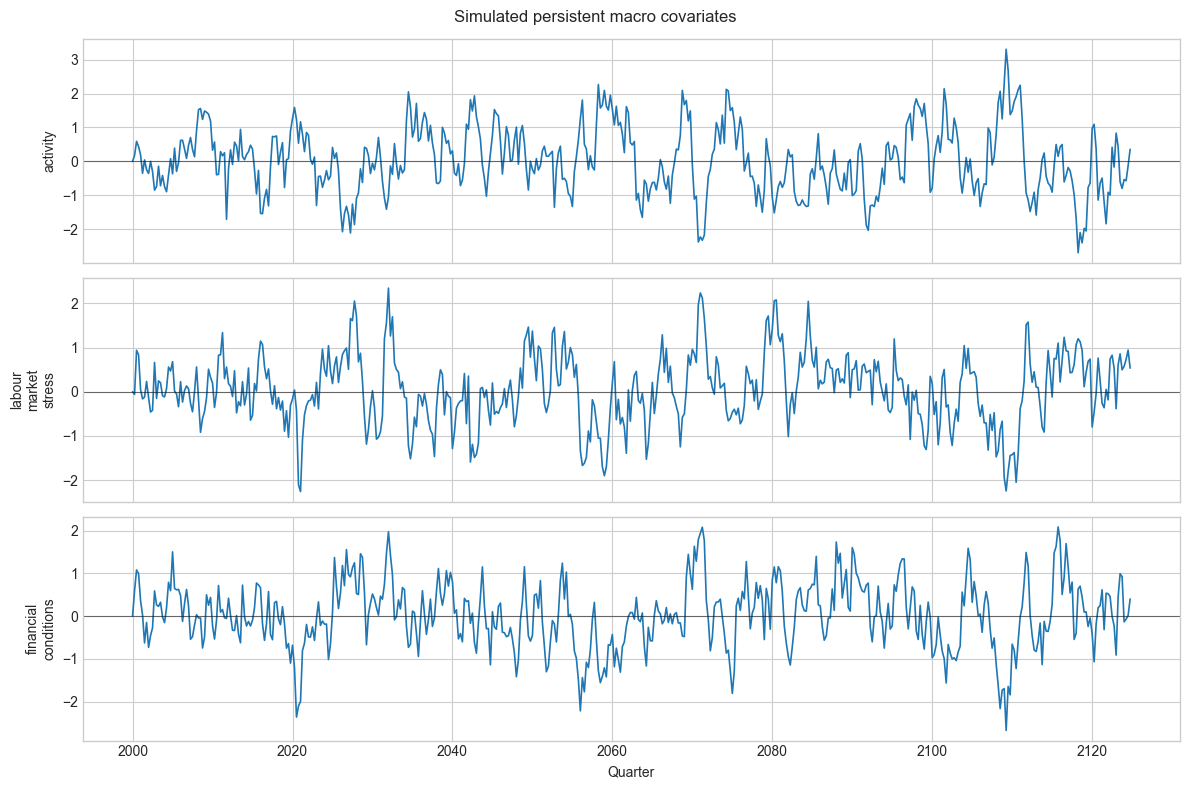

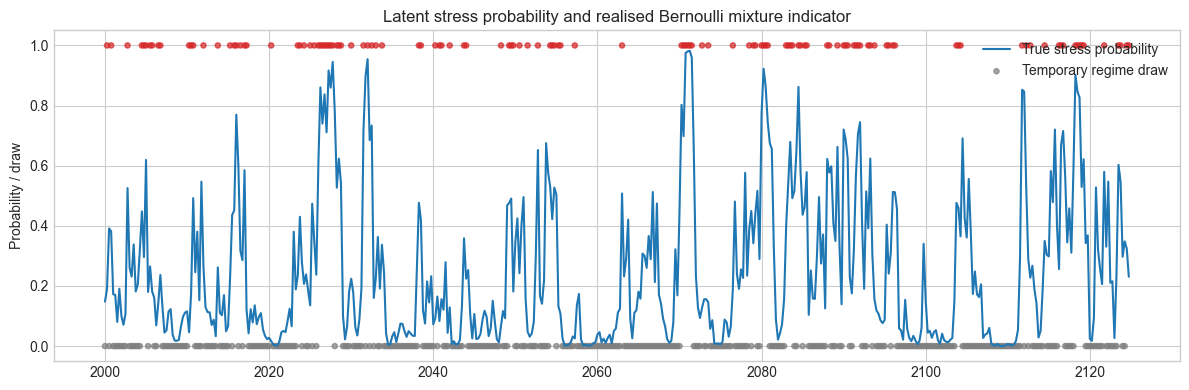

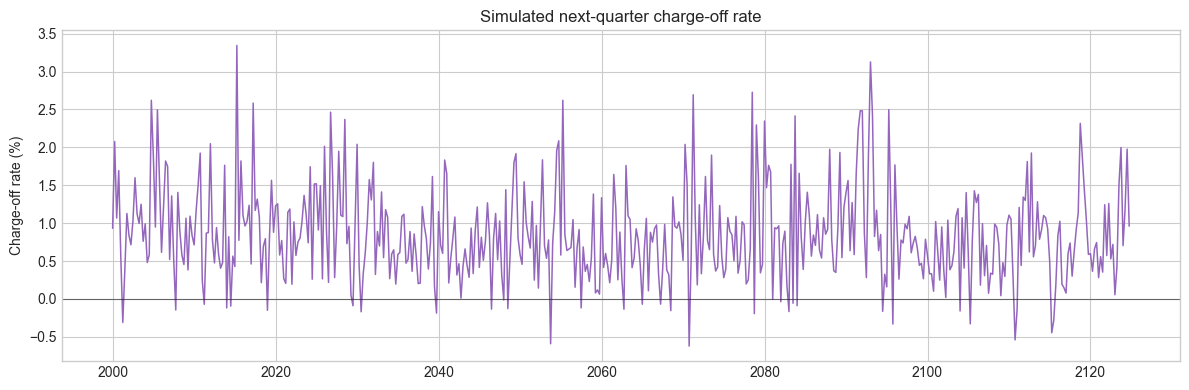

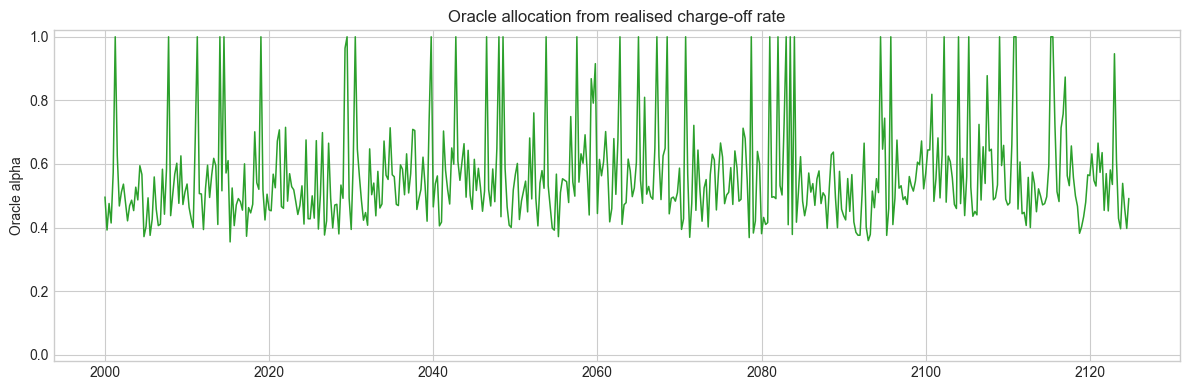

In [118]:
fig, axes = plt.subplots(len(MACRO_NAMES), 1, figsize=(12, 8), sharex=True)
for ax, col in zip(axes, MACRO_NAMES):
    ax.plot(sim_df["time"], sim_df[col], linewidth=1.2)
    ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
    ax.set_ylabel(col.replace("_", "\n"))
axes[-1].set_xlabel("Quarter")
fig.suptitle("Simulated persistent macro covariates", y=0.98)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sim_df["time"], sim_df["true_stress_probability"], color="tab:blue", label="True stress probability")
ax.scatter(
    sim_df["time"],
    sim_df["stress_regime"],
    color=np.where(sim_df["stress_regime"].eq(1), "tab:red", "tab:gray"),
    s=14,
    alpha=0.7,
    label="Temporary regime draw",
)
ax.set_ylim(-0.05, 1.05)
ax.set_ylabel("Probability / draw")
ax.set_title("Latent stress probability and realised Bernoulli mixture indicator")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sim_df["time"], 100 * sim_df["charge_off_rate"], color="tab:purple", linewidth=1.1)
ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
ax.set_ylabel("Charge-off rate (%)")
ax.set_title("Simulated next-quarter charge-off rate")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sim_df["time"], sim_df["oracle_alpha"], color="tab:green", linewidth=1.1)
ax.set_ylim(-0.02, 1.02)
ax.set_ylabel("Oracle alpha")
ax.set_title("Oracle allocation from realised charge-off rate")
fig.tight_layout()
plt.show()


## 6. Save synthetic panel

The saved panel contains only the variables required by the downstream simulation models: time index, macro covariates, true stress probability, temporary mixture indicator, charge-off rate, oracle allocation, and oracle utility.


In [119]:
output_dir = REPO_ROOT / "models" / "simulation" / "data"
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "simulated_variables.csv"

output_cols = [
    "time",
    *MACRO_NAMES,
    "true_stress_probability",
    "stress_regime",
    "charge_off_rate",
    "oracle_alpha",
    "oracle_utility",
]
sim_df[output_cols].to_csv(output_path, index=False)

print(f"Saved {len(sim_df)} rows to {output_path.relative_to(REPO_ROOT)}")
display(sim_df[output_cols].head())


Saved 500 rows to models/simulation/data/simulated_variables.csv


,time,activity,labour_market_stress,financial_conditions,true_stress_probability,stress_regime,charge_off_rate,oracle_alpha,oracle_utility
0,2000-01-01,0.000000,0.000000,0.000000,0.148047,0,0.009317,0.496157,1.201851
1,2000-04-01,0.176770,-0.058818,0.592134,0.189568,1,0.020767,0.392315,1.114687
2,2000-07-01,0.591094,0.939686,1.079505,0.391229,0,0.010681,0.475773,1.187070
3,2000-10-01,0.436784,0.837702,0.992240,0.381769,1,0.016926,0.414426,1.137065
4,2001-01-01,0.195185,0.046005,0.355706,0.172237,0,0.005587,0.573180,1.254565
